# *Traffic Sign Recognizer - 99% accuracy*

## Importing Required Libraries

In [30]:
import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score
np.random.seed(42)

from matplotlib import style
style.use('fivethirtyeight')

In [31]:

import os
import zipfile

In [32]:
TMP_DATA_DIR = "data/tmp"
TMP_LABELS_DIR = os.path.join(TMP_DATA_DIR, "GTSRB/Final_Test")

TRAINING_DATA_DIR = "data/training"
VALIDATION_DATA_DIR = "data/validation"

## Assigning Path for Dataset

In [34]:
data_dir = '../dataset/raw/gtsrb'
train_path = data_dir + '/Train'
test_path = data_dir + '/Test'

# Resizing the images to 30x30x3
IMG_HEIGHT = 30
IMG_WIDTH = 30
channels = 3

## Finding Total Classes

In [35]:

NUM_CATEGORIES = len(os.listdir(train_path))
NUM_CATEGORIES

43

In [36]:
# Label Overview
classes = { 0:'Speed limit (20km/h)',
            1:'Speed limit (30km/h)', 
            2:'Speed limit (50km/h)', 
            3:'Speed limit (60km/h)', 
            4:'Speed limit (70km/h)', 
            5:'Speed limit (80km/h)', 
            6:'End of speed limit (80km/h)', 
            7:'Speed limit (100km/h)', 
            8:'Speed limit (120km/h)', 
            9:'No passing', 
            10:'No passing veh over 3.5 tons', 
            11:'Right-of-way at intersection', 
            12:'Priority road', 
            13:'Yield', 
            14:'Stop', 
            15:'No vehicles', 
            16:'Veh > 3.5 tons prohibited', 
            17:'No entry', 
            18:'General caution', 
            19:'Dangerous curve left', 
            20:'Dangerous curve right', 
            21:'Double curve', 
            22:'Bumpy road', 
            23:'Slippery road', 
            24:'Road narrows on the right', 
            25:'Road work', 
            26:'Traffic signals', 
            27:'Pedestrians', 
            28:'Children crossing', 
            29:'Bicycles crossing', 
            30:'Beware of ice/snow',
            31:'Wild animals crossing', 
            32:'End speed + passing limits', 
            33:'Turn right ahead', 
            34:'Turn left ahead', 
            35:'Ahead only', 
            36:'Go straight or right', 
            37:'Go straight or left', 
            38:'Keep right', 
            39:'Keep left', 
            40:'Roundabout mandatory', 
            41:'End of no passing', 
            42:'End no passing veh > 3.5 tons' }

## Visualizing The Dataset

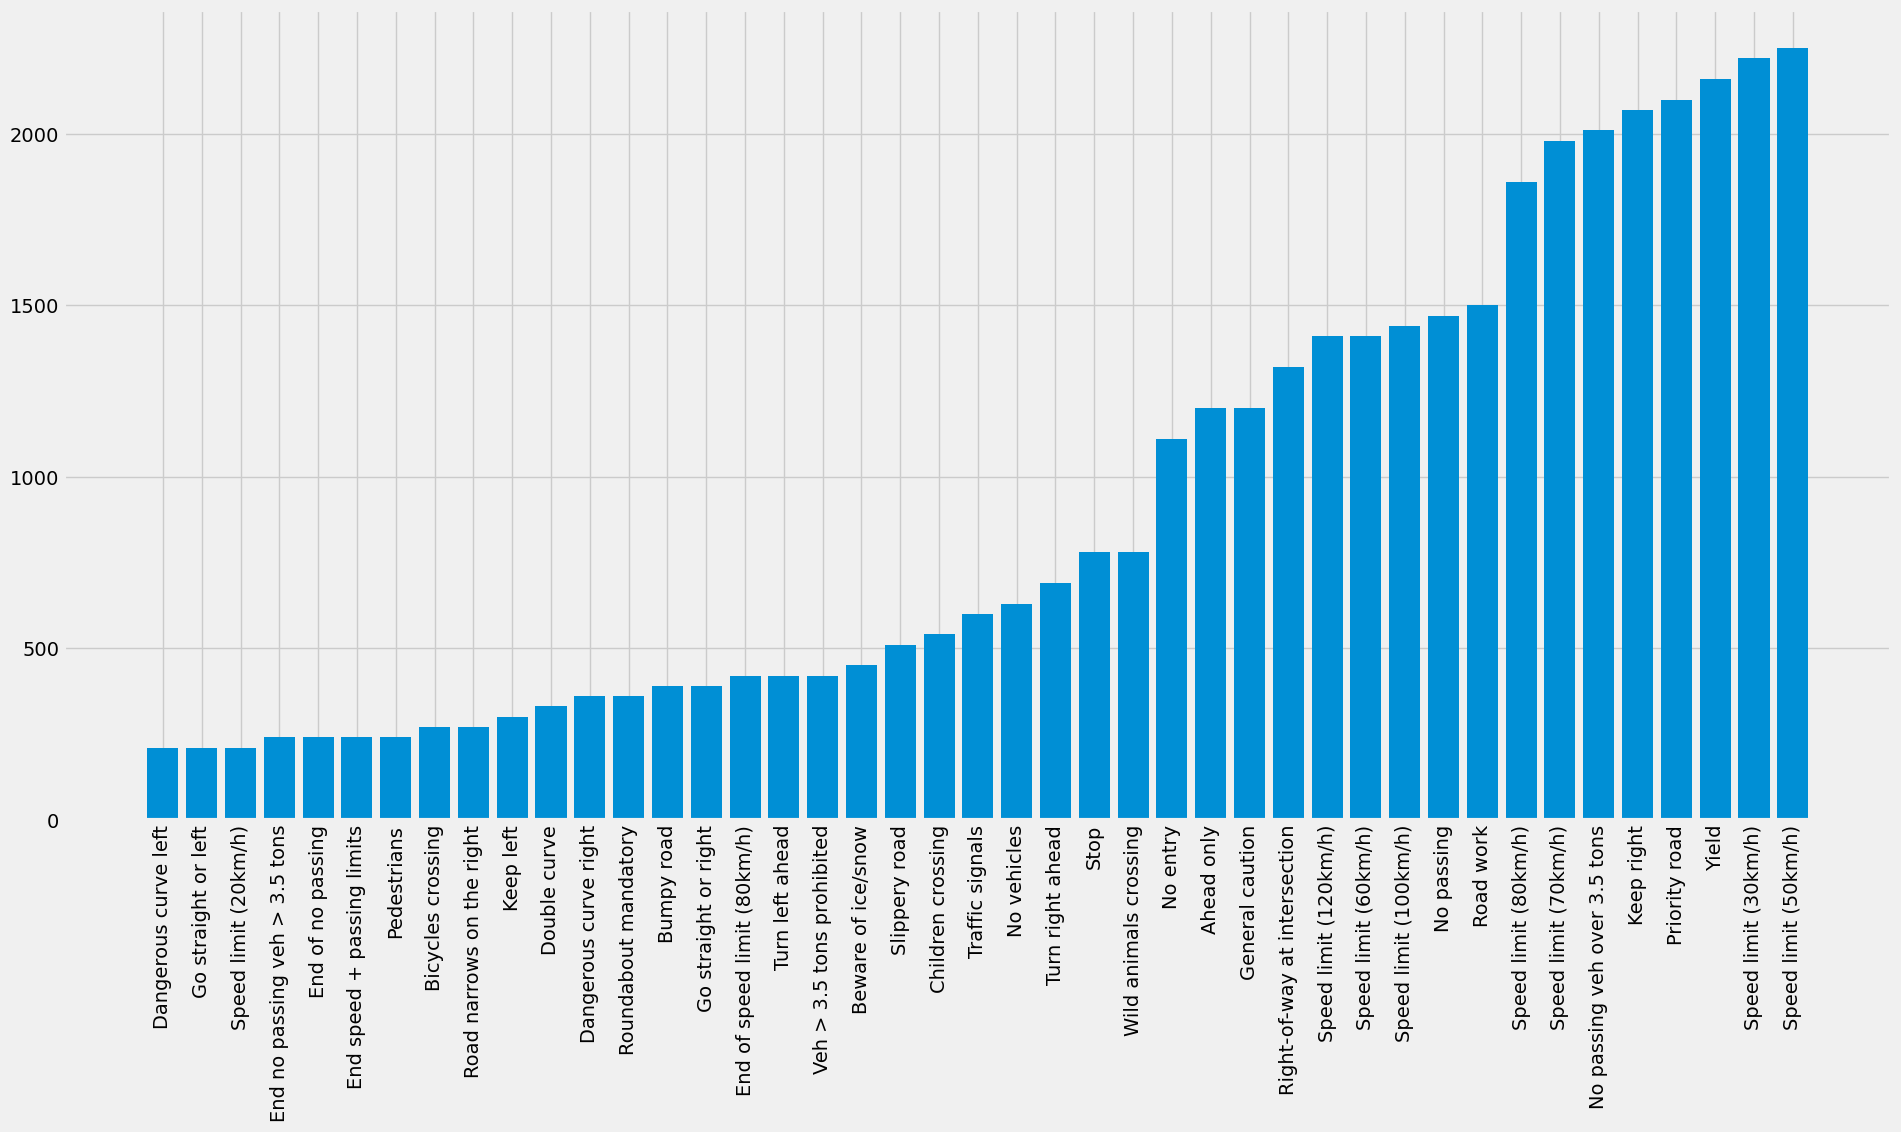

In [24]:
folders = os.listdir(train_path)

train_number = []
class_num = []

for folder in folders:
    train_files = os.listdir(train_path + '/' + folder)
    train_number.append(len(train_files))
    class_num.append(classes[int(folder)])
    
# Sorting the dataset on the basis of number of images in each class
zipped_lists = zip(train_number, class_num)
sorted_pairs = sorted(zipped_lists)
tuples = zip(*sorted_pairs)
train_number, class_num = [ list(tuple) for tuple in  tuples]

# Plotting the number of images in each class
plt.figure(figsize=(21,10))  
plt.bar(class_num, train_number)
plt.xticks(class_num, rotation='vertical')
plt.show()

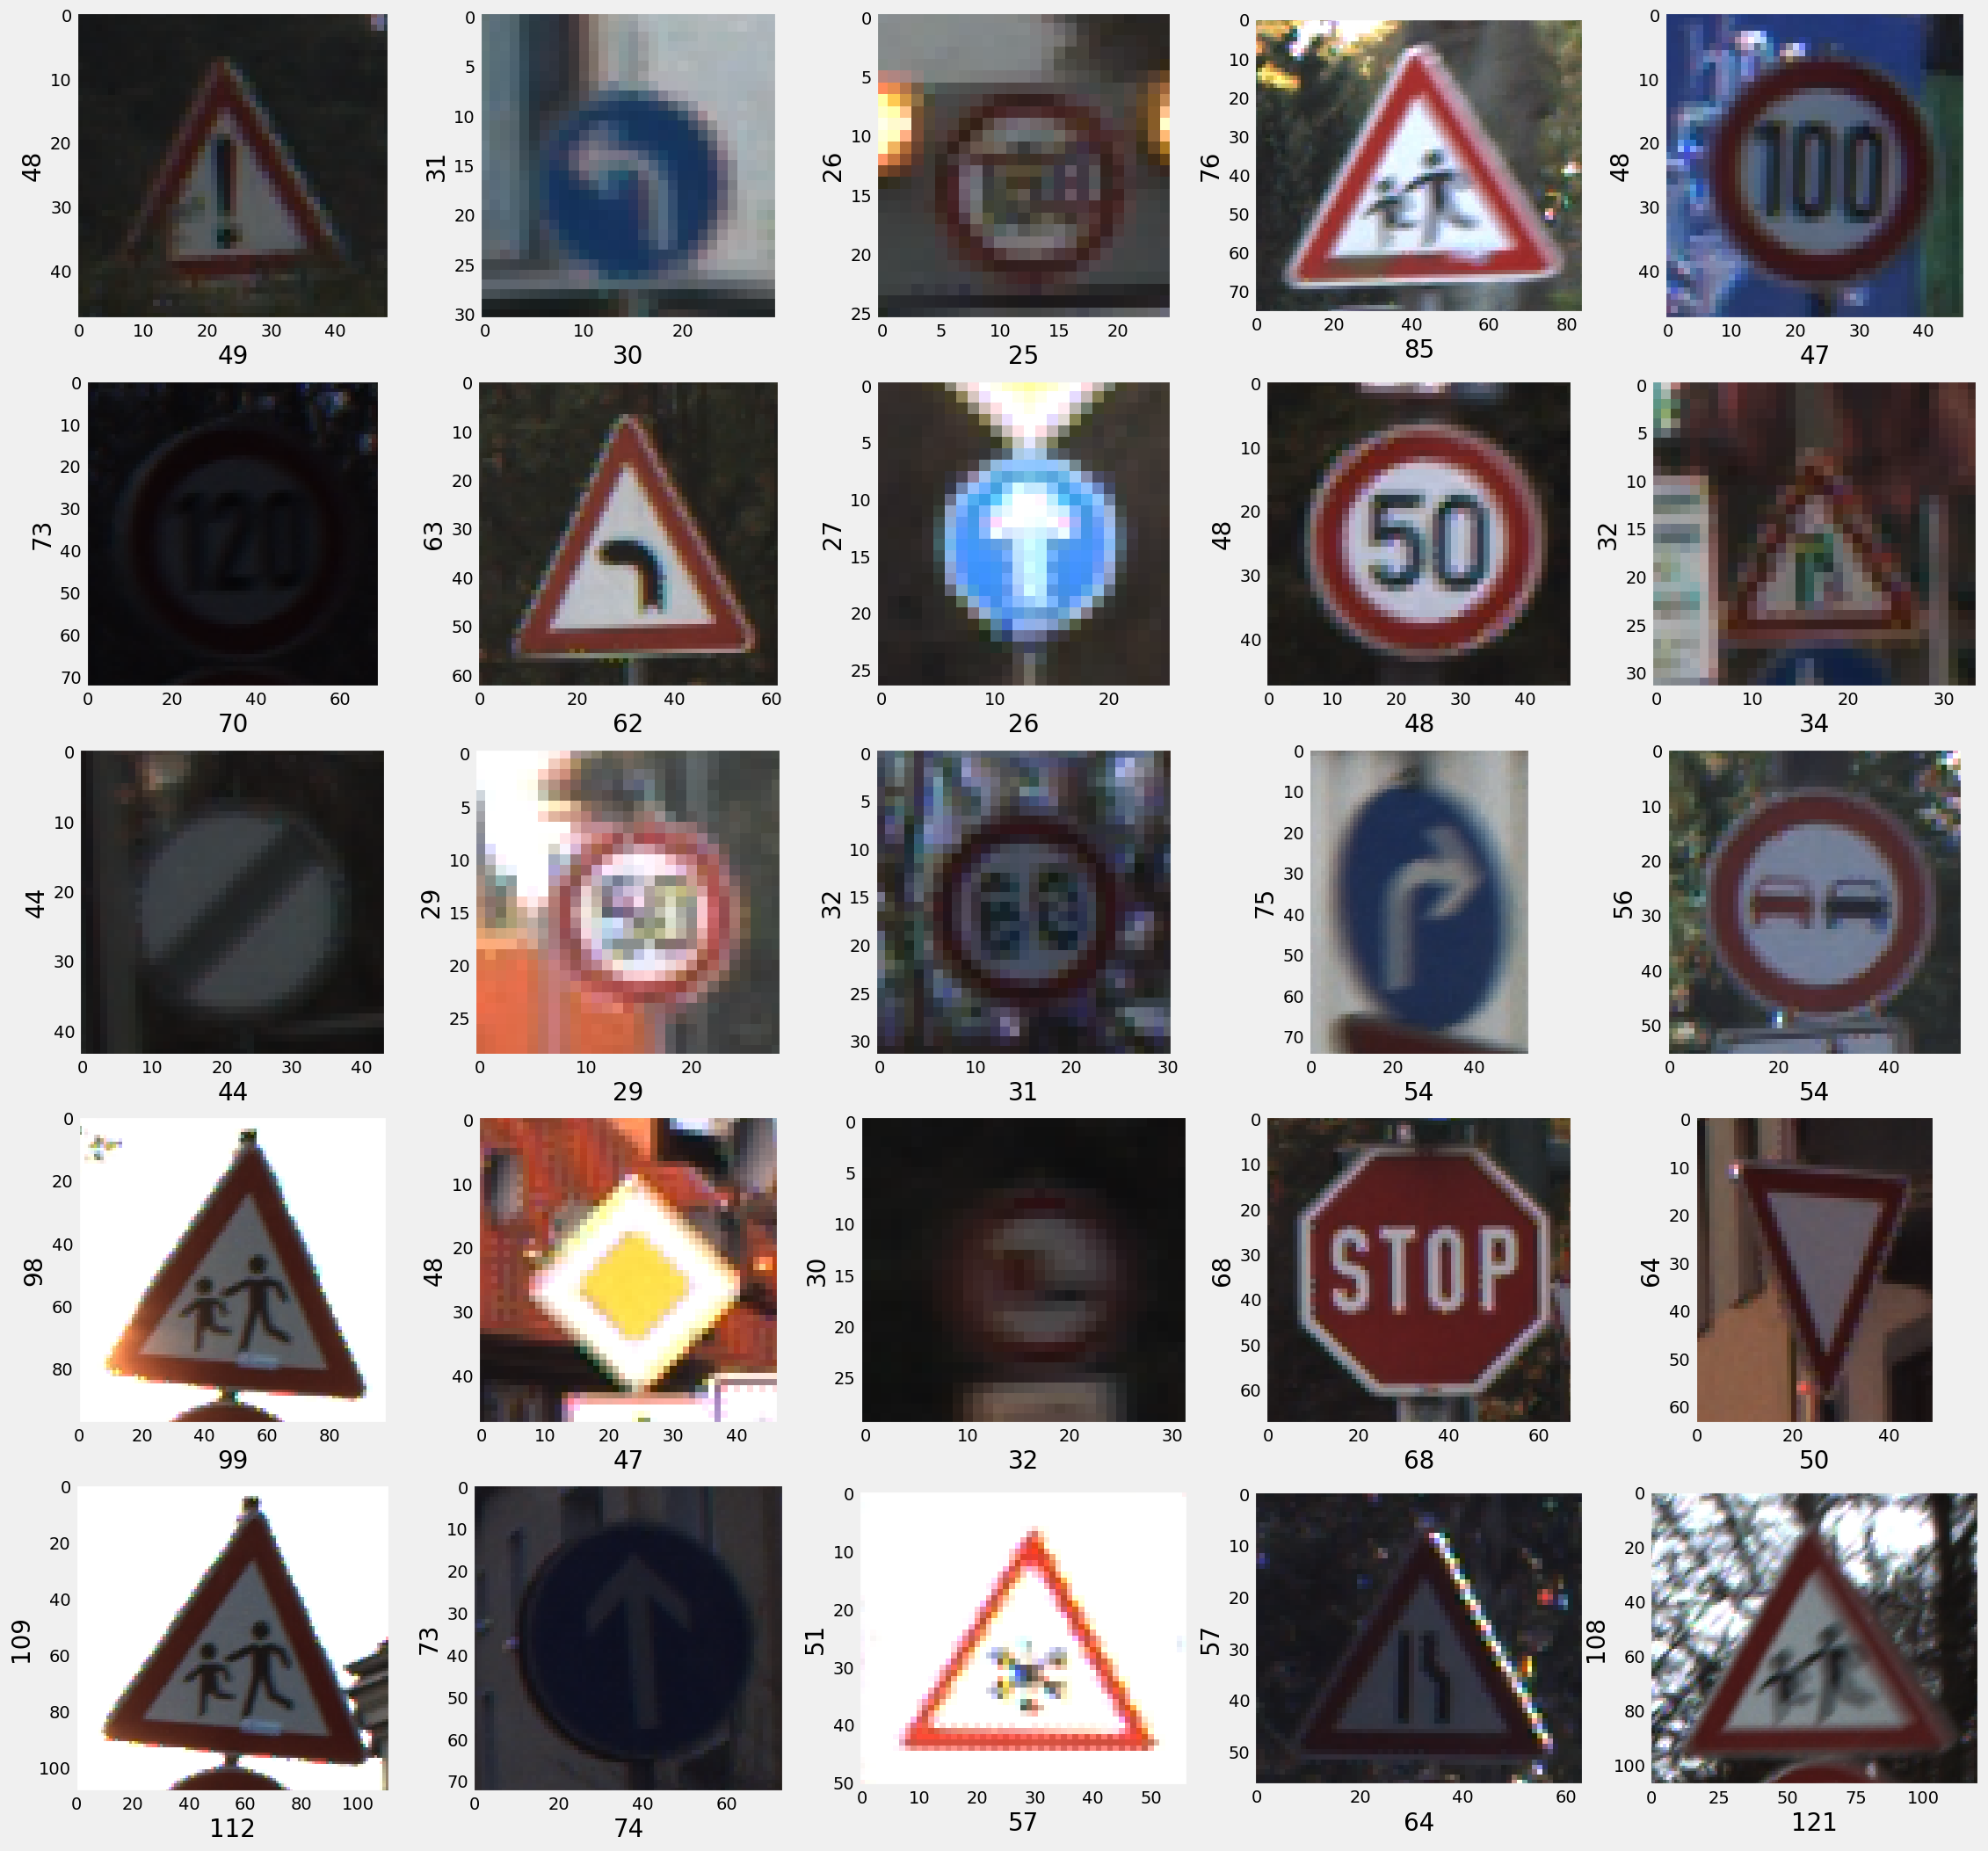

In [25]:
# Visualizing 25 random images from test data
import random
from matplotlib.image import imread

test = pd.read_csv(data_dir + '/Test.csv')
imgs = test["Path"].values

plt.figure(figsize=(25,25))

for i in range(1,26):
    plt.subplot(5,5,i)
    random_img_path = data_dir + '/' + random.choice(imgs)
    rand_img = imread(random_img_path)
    plt.imshow(rand_img)
    plt.grid(False)
    plt.xlabel(rand_img.shape[1], fontsize = 20)#width of image
    plt.ylabel(rand_img.shape[0], fontsize = 20)#height of image

## Collecting the Training Data

In [26]:
image_data = []
image_labels = []

for i in range(NUM_CATEGORIES):
    path = data_dir + '/Train/' + str(i)
    images = os.listdir(path)

    for img in images:
        try:
            image = cv2.imread(path + '/' + img)
            image_fromarray = Image.fromarray(image, 'RGB')
            resize_image = image_fromarray.resize((IMG_HEIGHT, IMG_WIDTH))
            image_data.append(np.array(resize_image))
            image_labels.append(i)
        except:
            print("Error in " + img)

# Changing the list to numpy array
image_data = np.array(image_data)
image_labels = np.array(image_labels)

print(image_data.shape, image_labels.shape)

C:\Users\sreek\AppData\Local\Temp\ipykernel_19028\2954435099.py:11: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image_fromarray = Image.fromarray(image, 'RGB')


(39209, 30, 30, 3) (39209,)


In [8]:
image_labels

array([ 0,  0,  0, ..., 42, 42, 42])

## Shuffling the training data

In [27]:
image_data.shape[0]

39209

In [29]:
shuffle_indexes=np.arange(image_data.shape[0])
np.random.shuffle(shuffle_indexes)
print(shuffle_indexes)
print(image_labels)

[35386 19289  6597 ...  6521 28911  8995]
[ 0  0  0 ... 42 42 42]


In [30]:
shuffle_indexes = np.arange(image_data.shape[0])
np.random.shuffle(shuffle_indexes)
image_data = image_data[shuffle_indexes]
image_labels = image_labels[shuffle_indexes]

In [31]:
image_labels

array([21, 12, 34, ..., 10,  2,  2])

## Splitting the data into train and validation set

In [32]:
X_train, X_val, y_train, y_val = train_test_split(image_data, image_labels, test_size=0.3, random_state=42, shuffle=True)

X_train = X_train/255 
X_val = X_val/255

print("X_train.shape", X_train.shape)
print("X_valid.shape", X_val.shape)
print("y_train.shape", y_train.shape)
print("y_valid.shape", y_val.shape)

X_train.shape (27446, 30, 30, 3)
X_valid.shape (11763, 30, 30, 3)
y_train.shape (27446,)
y_valid.shape (11763,)


## One hot encoding the labels

In [33]:
y_train = keras.utils.to_categorical(y_train, NUM_CATEGORIES)
y_val = keras.utils.to_categorical(y_val, NUM_CATEGORIES)

print(y_train.shape)
print(y_val.shape)

(27446, 43)
(11763, 43)


In [34]:
np.save(os.path.join(data_dir, 'X_train.npy'), X_train)
np.save(os.path.join(data_dir, 'y_train.npy'), y_train)
np.save(os.path.join(data_dir, 'X_val.npy'), X_val)
np.save(os.path.join(data_dir, 'y_val.npy'), y_val)

## Making the model

In [35]:
model = keras.models.Sequential([    
    keras.layers.Conv2D(filters=16, kernel_size=(3,3), activation='relu', input_shape=(IMG_HEIGHT,IMG_WIDTH,channels)),
    keras.layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu'),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),
    keras.layers.BatchNormalization(axis=-1),
    
    keras.layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    keras.layers.Conv2D(filters=128, kernel_size=(3,3), activation='relu'),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),
    keras.layers.BatchNormalization(axis=-1),
    
    keras.layers.Flatten(),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(rate=0.5),
    
    keras.layers.Dense(43, activation='softmax')
])
model.summary() 

c:\Users\sreek\anaconda3\envs\tf_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 13, 13, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 9, 9, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        22,059 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,171,275 (4.47 MB)

 Trainable params: 1,169,931 (4.46 MB)

 Non-trainable params: 1,344 (5.25 KB)

In [41]:
lr = 0.001
epochs = 30
# Define a LearningRateSchedule object
lr_schedule = tf.keras.optimizers.schedules.InverseTimeDecay(
    initial_learning_rate=lr,
    decay_steps=10000,
    decay_rate=lr / (epochs * 0.5)
)
opt = Adam(learning_rate=lr_schedule )
model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

## Augmenting the data and training the model

In [16]:
y_train.shape

(27446, 43)

In [17]:
aug = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.15,
    horizontal_flip=False,
    vertical_flip=False,
    fill_mode="nearest")

history = model.fit(aug.flow(X_train, y_train, batch_size=32), epochs=epochs, validation_data=(X_val, y_val))

Epoch 1/30


C:\Users\sreek\anaconda3\envs\tf_env\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


858/858 ━━━━━━━━━━━━━━━━━━━━ 26s 26ms/step - accuracy: 0.6794 - loss: 1.1866 - val_accuracy: 0.9626 - val_loss: 0.1264
Epoch 2/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.9374 - loss: 0.2035 - val_accuracy: 0.9746 - val_loss: 0.0876
Epoch 3/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 22s 25ms/step - accuracy: 0.9647 - loss: 0.1168 - val_accuracy: 0.9911 - val_loss: 0.0275
Epoch 4/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.9740 - loss: 0.0855 - val_accuracy: 0.9912 - val_loss: 0.0293
Epoch 5/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.9772 - loss: 0.0752 - val_accuracy: 0.9866 - val_loss: 0.0431
Epoch 6/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.9776 - loss: 0.0717 - val_accuracy: 0.9939 - val_loss: 0.0208
Epoch 7/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.9799 - loss: 0.0679 - val_accuracy: 0.9922 - val_loss: 0.0290
Epoch 8/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.9830 - loss: 0.0567 - val_accurac

## Evaluating the model

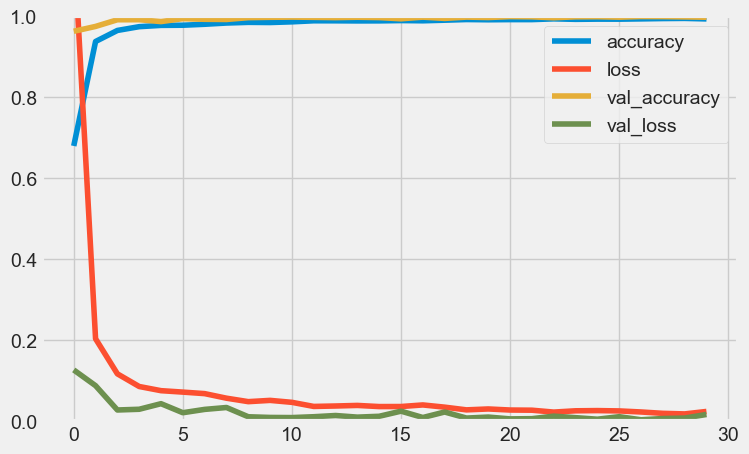

In [18]:
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

## Loading the test data and running the predictions

In [18]:
def prepare_test_data(test_path):
    test_image_data = []
    test_image_labels = []
    
    test = pd.read_csv(data_dir + '/Test.csv')
    imgs = test["Path"].values
    labels = test["ClassId"].values

    for i in range(len(imgs)):
        try:
            image = cv2.imread(data_dir + '/' + imgs[i])
            image_fromarray = Image.fromarray(image, 'RGB')
            resize_image = image_fromarray.resize((IMG_HEIGHT, IMG_WIDTH))
            test_image_data.append(np.array(resize_image))
            test_image_labels.append(labels[i])
        except:
            print("Error in " + imgs[i])
    
    test_image_data = np.array(test_image_data)
    test_image_labels = np.array(test_image_labels)
    test_image_data = test_image_data/255
    test_image_labels = keras.utils.to_categorical(test_image_labels, 43)
    return test_image_data, test_image_labels

In [19]:
X_test, y_test = prepare_test_data(test_path)
#np.save(os.path.join('../dataset/Processed', 'X_test.npy'), X_test)
#np.save(os.path.join('../dataset/Processed', 'y_test.npy'), y_test)
print("X_test.shape", X_test.shape)
print("y_test.shape", y_test.shape)

C:\Users\sreek\AppData\Local\Temp\ipykernel_23880\33191963.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image_fromarray = Image.fromarray(image, 'RGB')


X_test.shape (12630, 30, 30, 3)
y_test.shape (12630, 43)


In [20]:
np.save(os.path.join('../dataset/Processed', 'X_test.npy'), X_test)
np.save(os.path.join('../dataset/Processed', 'y_test.npy'), y_test)

In [44]:
def evaluate_test(model_trained):
    test = pd.read_csv(data_dir + '/Test.csv')

    labels = test["ClassId"].values
    imgs = test["Path"].values

    data =[]

    for img in imgs:
        try:
            image = cv2.imread(data_dir + '/' +img)
            image_fromarray = Image.fromarray(image, 'RGB')
            resize_image = image_fromarray.resize((IMG_HEIGHT, IMG_WIDTH))
            data.append(np.array(resize_image))
        except:
            print("Error in " + img)
    X_test = np.array(data)
    X_test = X_test/255
    
    predictions = model_trained.predict(X_test)
    
    # 2. Use `np.argmax()` to get the class index with the highest probability
    pred = np.argmax(predictions, axis=1)
    
    #Accuracy with the test data
    print('Test Data accuracy: ',accuracy_score(labels, pred)*100)

## Visualizing the confusion matrix

In [20]:
from sklearn.metrics import confusion_matrix
cf = confusion_matrix(labels, pred)

<Axes: >

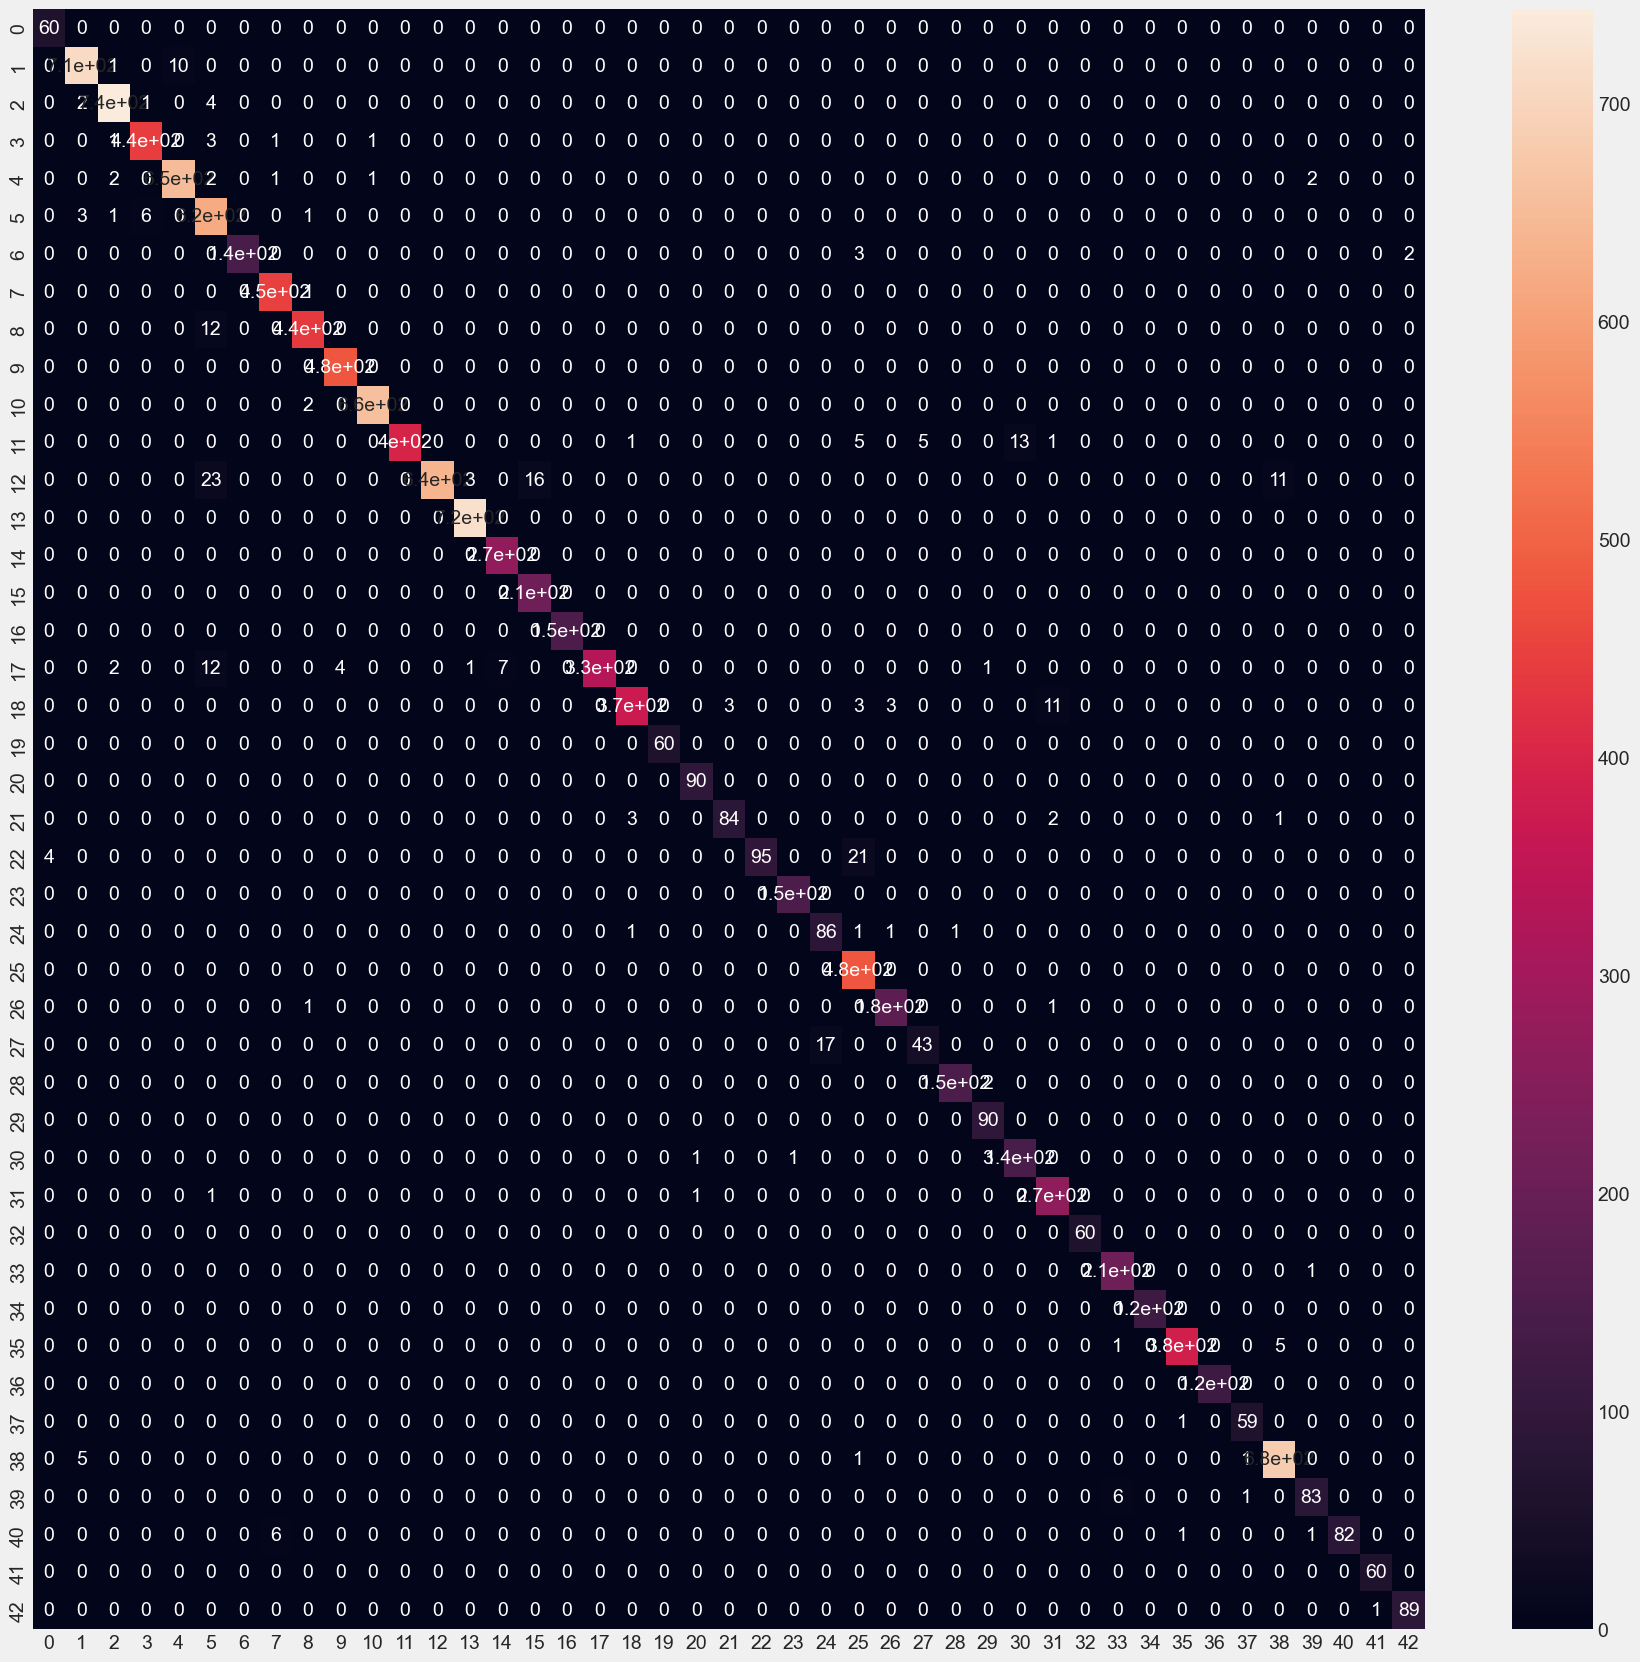

In [21]:
import seaborn as sns
df_cm = pd.DataFrame(cf, index = classes,  columns = classes)
plt.figure(figsize = (20,20))
sns.heatmap(df_cm, annot=True)

## Classification report

In [22]:
from sklearn.metrics import classification_report

print(classification_report(labels, pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97        60
           1       0.99      0.98      0.99       720
           2       0.99      0.99      0.99       750
           3       0.98      0.99      0.99       450
           4       0.98      0.99      0.99       660
           5       0.92      0.98      0.95       630
           6       1.00      0.97      0.98       150
           7       0.98      1.00      0.99       450
           8       0.99      0.97      0.98       450
           9       0.99      1.00      1.00       480
          10       1.00      1.00      1.00       660
          11       1.00      0.94      0.97       420
          12       1.00      0.92      0.96       690
          13       0.99      1.00      1.00       720
          14       0.97      1.00      0.99       270
          15       0.93      1.00      0.96       210
          16       1.00      1.00      1.00       150
          17       1.00    

## Predictions on Test Data

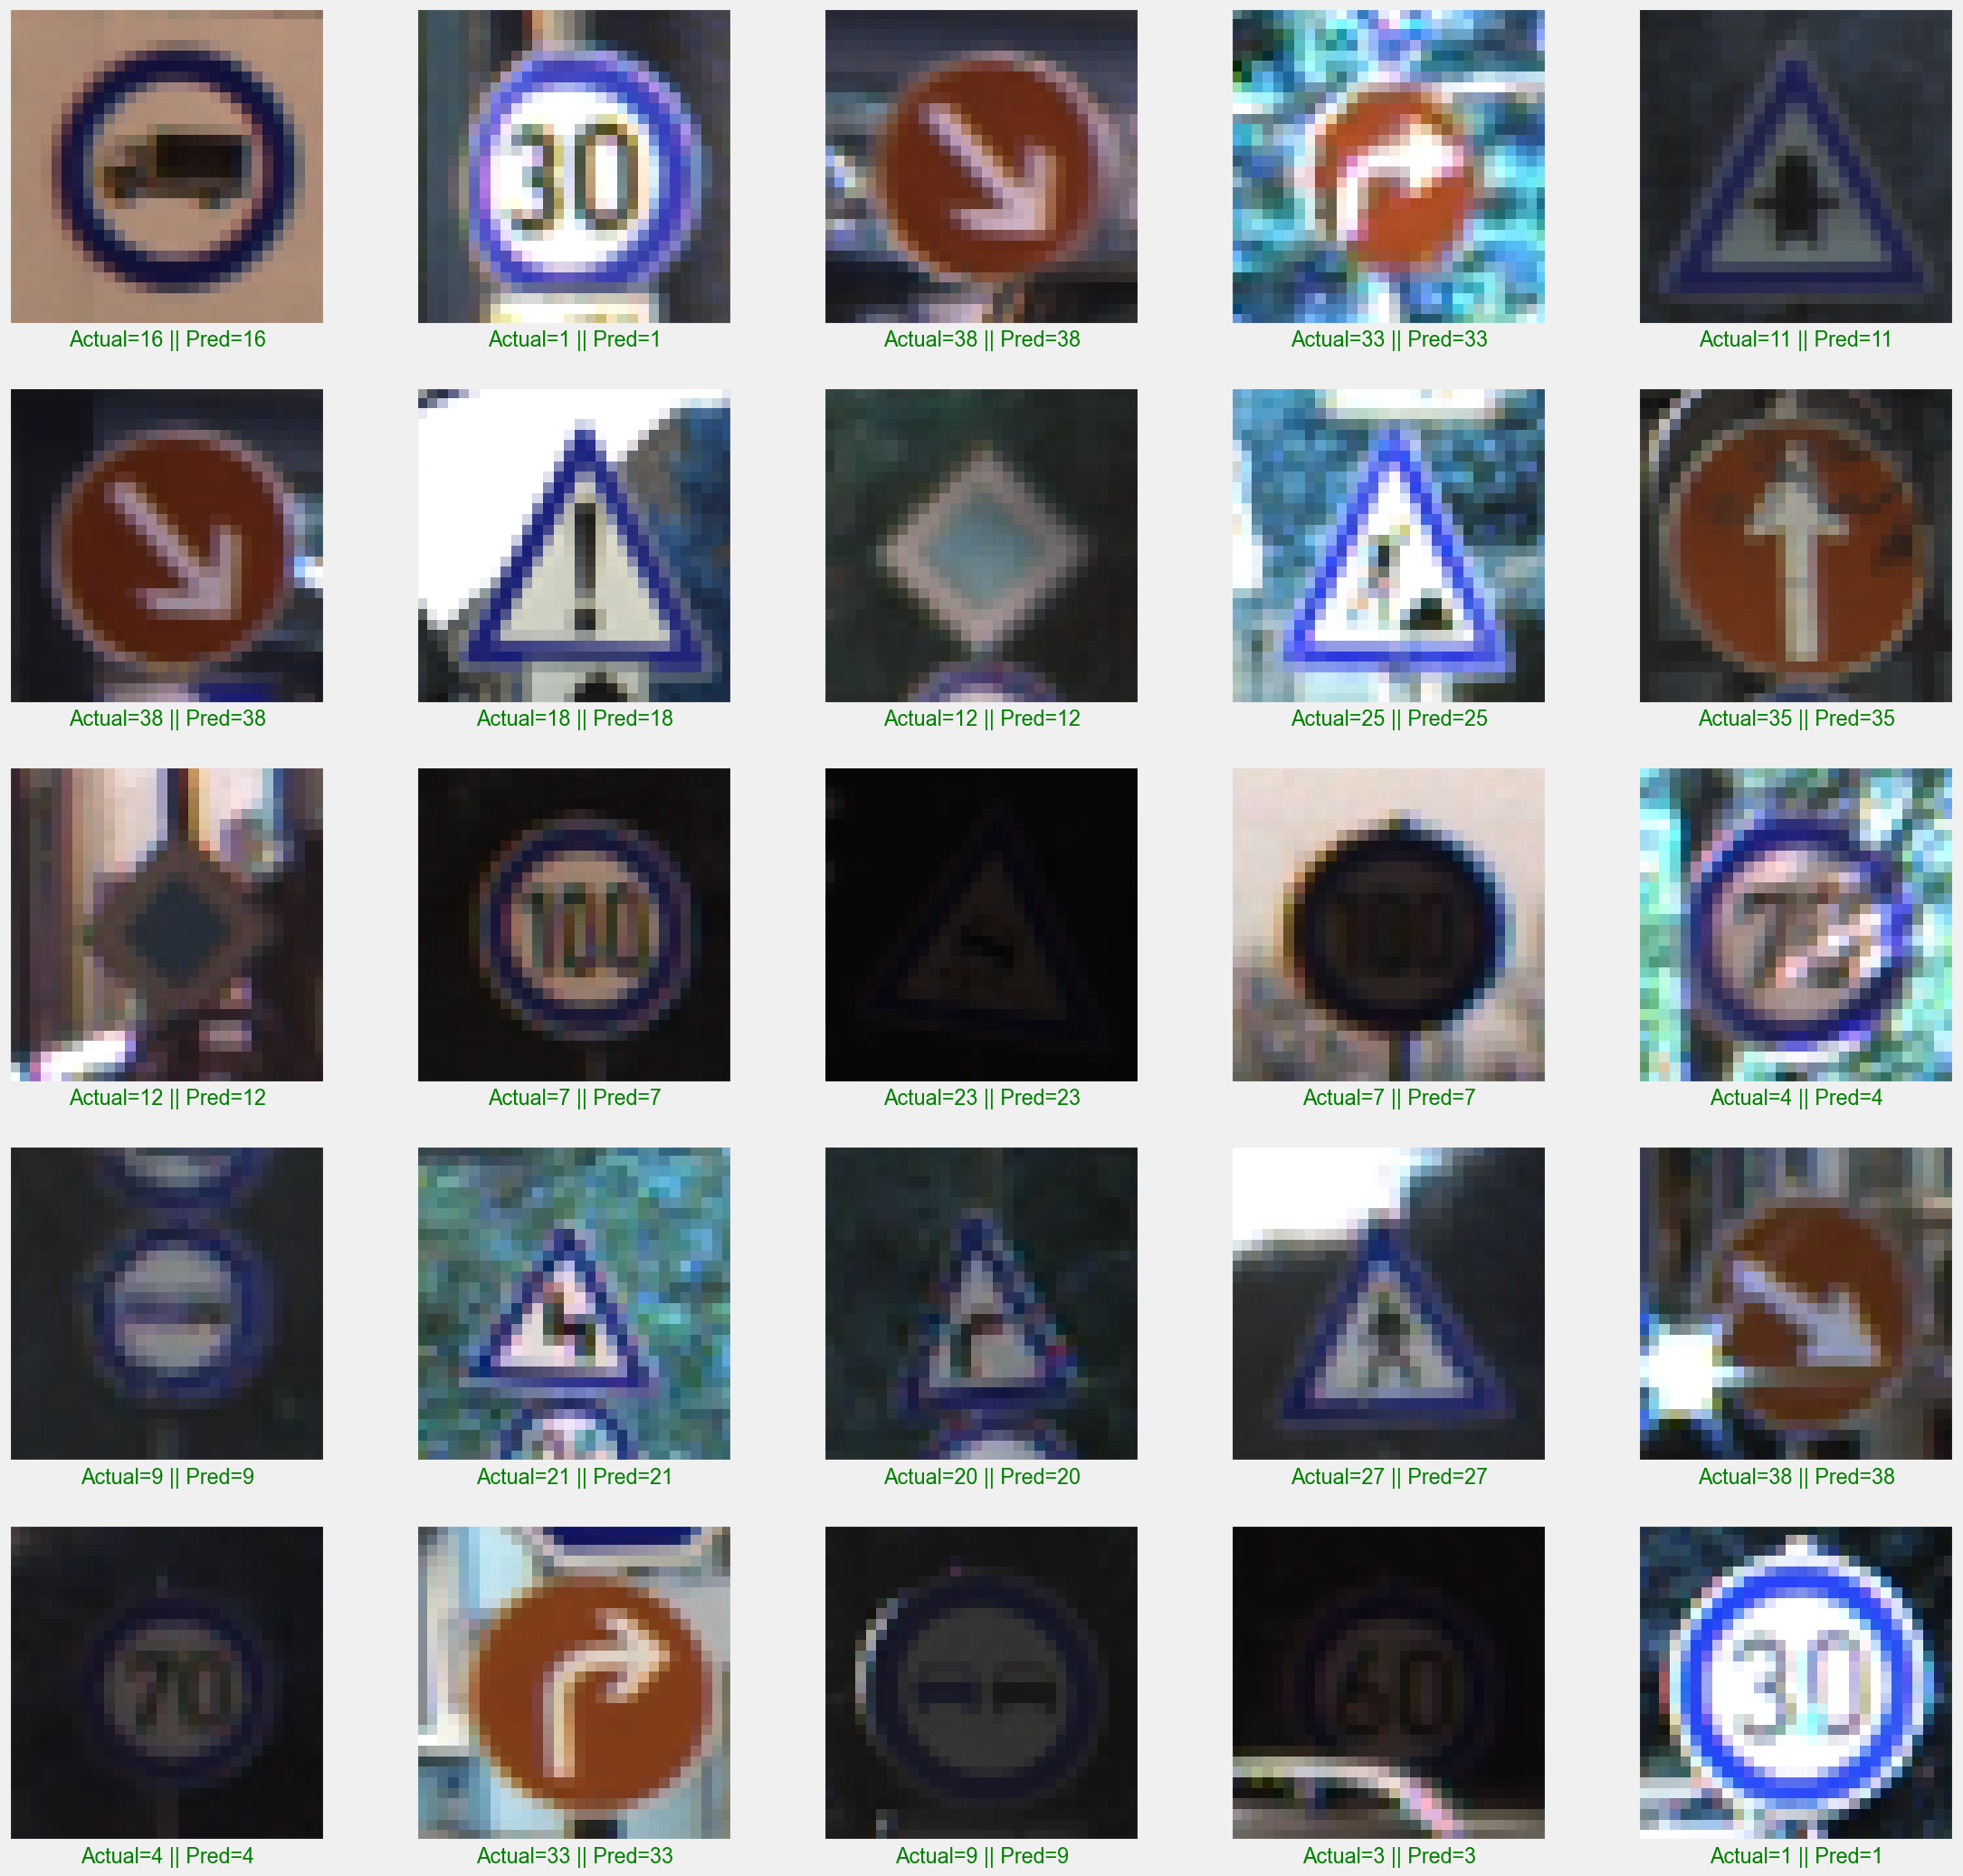

In [23]:
plt.figure(figsize = (25, 25))

start_index = 0
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    prediction = pred[start_index + i]
    actual = labels[start_index + i]
    col = 'g'
    if prediction != actual:
        col = 'r'
    plt.xlabel('Actual={} || Pred={}'.format(actual, prediction), color = col)
    plt.imshow(X_test[start_index + i])
plt.show()

In [25]:
import os
os.makedirs("./model", exist_ok=True)
model.save("./model/traffic_sign_dcnn97.keras")

print("\n✅ Model saved to '/model/traffic_sign_dcnn97.keras'")
print("You can now convert it to TensorFlow.js using:")
print("tensorflowjs_converter --input_format=tf_saved_model --output_format=tfjs_graph_model saved_model/traffic_sign_mobilenetv2 web_model/")


✅ Model saved to 'model/traffic_sign_custom_model2.keras'
You can now convert it to TensorFlow.js using:
tensorflowjs_converter --input_format=tf_saved_model --output_format=tfjs_graph_model saved_model/traffic_sign_mobilenetv2 web_model/


CAM Model

In [37]:
from tensorflow import keras
from tensorflow.keras import layers

def build_cam_model(img_height, img_width, channels, num_classes=43):

    inputs = keras.Input(shape=(img_height, img_width, channels))

    # --- Block 1 ---
    x = layers.Conv2D(16, (3,3), activation='relu')(inputs)
    x = layers.Conv2D(32, (3,3), activation='relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.BatchNormalization()(x)

    # --- Block 2 ---
    x = layers.Conv2D(64, (3,3), activation='relu')(x)
    x = layers.Conv2D(128, (3,3), activation='relu', name="last_conv")(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.BatchNormalization()(x)

    # --- Gap + Classifier ---
    x = layers.GlobalAveragePooling2D()(x)   # CAM compatible
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs, name="cam_cnn_model")
    
    

cam_model = build_cam_model(IMG_HEIGHT, IMG_WIDTH, channels)
cam_model.summary()


Model: "cam_cnn_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 30, 30, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 26, 26, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 13, 13, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ last_conv (Conv2D)              │ (None, 9, 9, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 43)             │        22,059 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 188,235 (735.29 KB)

 Trainable params: 186,891 (730.04 KB)

 Non-trainable params: 1,344 (5.25 KB)

In [38]:
cam_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [39]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        "best_cam_model.keras",
        save_best_only=True,
        monitor="val_loss",
        mode="min"
    ),
    keras.callbacks.EarlyStopping(
        patience=5,
        monitor="val_loss",
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2
    )
]


In [42]:
aug = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.15,
    horizontal_flip=False,
    vertical_flip=False,
    fill_mode="nearest")

history_cam_output = cam_model.fit(aug.flow(X_train, y_train, batch_size=32), epochs=epochs, validation_data=(X_val, y_val))

Epoch 1/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.6332 - loss: 1.3691 - val_accuracy: 0.8211 - val_loss: 0.5946
Epoch 2/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 22s 25ms/step - accuracy: 0.9476 - loss: 0.1725 - val_accuracy: 0.9783 - val_loss: 0.0701
Epoch 3/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - accuracy: 0.9709 - loss: 0.0954 - val_accuracy: 0.9898 - val_loss: 0.0360
Epoch 4/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.9731 - loss: 0.0853 - val_accuracy: 0.9826 - val_loss: 0.0532
Epoch 5/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.9814 - loss: 0.0596 - val_accuracy: 0.8716 - val_loss: 0.4552
Epoch 6/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.9785 - loss: 0.0714 - val_accuracy: 0.9641 - val_loss: 0.1416
Epoch 7/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 22s 25ms/step - accuracy: 0.9814 - loss: 0.0634 - val_accuracy: 0.9965 - val_loss: 0.0115
Epoch 8/30
858/858 ━━━━━━━━━━━━━━━━━━━━ 22s 25ms/step - accuracy: 0.9850 - loss: 0.0499 - 

In [46]:
evaluate_test(cam_model)

C:\Users\sreek\AppData\Local\Temp\ipykernel_19028\431718732.py:12: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image_fromarray = Image.fromarray(image, 'RGB')


395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Test Data accuracy:  97.66429136975455


Grad-CAM (Gradient-weighted Class Activation Mapping) visualization creates heatmaps to show which parts of an image a Convolutional Neural Network (CNN) focuses on for a specific classification, offering explainability by highlighting important regions that influence the model's decision, like stripes on a tiger or ears on a cat, making "black box" models more transparent. It works by using gradients from the target output to weight feature maps from the last convolutional layer, generating a class-specific heatmap that reveals the model's reasoning. 

In [29]:
import numpy as np
import tensorflow as tf
import cv2

def make_gradcam_heatmap(img_array, model, last_conv_layer_name="last_conv"):
    # 1. create a model that maps the input image to the activations
    # of the last conv layer as well as the output predictions
    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output,
        ]
    )
    # 2. compute the gradient of the top predicted class for our input image
    # with respect to the activations of the last conv layer
    with tf.GradientTape() as tape:
        conv_output, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        pred_output = predictions[:, pred_index]

    # 3. This is the gradient of the output neuron (top predicted)
    # with regard to the output feature map of the last conv layer
    grads = tape.gradient(pred_output, conv_output)
    
    # This is a vector where each entry is the mean intensity of the gradient
    # over a specific feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    #  multiply each channel in the feature map array
    # by "how important this channel is" with regard to the top predicted class
    # then sum all the channels to obtain the heatmap class activation
    conv_output = conv_output[0]
    #heatmap = tf.reduce_sum(pooled_grads * conv_output, axis=-1)
    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # For visualization purpose, we will also normalize the heatmap between 0 & 1
    heatmap = np.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-9)
    return heatmap.numpy(), int(pred_index)


In [53]:
train_path

'../data/raw/gtsrb/Train'

In [42]:
best_cam_model = keras.models.load_model("../checkpoints/grid_33/best.keras")
best_cam_model.summary()

Model: "grid_33"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 30, 30, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 26, 26, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 13, 13, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 9, 9, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 43)             │        22,059 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 562,019 (2.14 MB)

 Trainable params: 186,891 (730.04 KB)

 Non-trainable params: 1,344 (5.25 KB)

 Optimizer params: 373,784 (1.43 MB)

In [43]:
import PIL.Image as pilimage
test_img_path = train_path+'/29/00029_00008_00029.png'
#test_img_path = train_path+'/5/00005_00000_00029.png'
#test_img_path = data_dir+'/Meta/29.png'
test_data=[]       
test_image = cv2.imread(test_img_path)
test_image_fromarray = pilimage.fromarray(test_image, 'RGB')
test_resize_image = test_image_fromarray.resize((IMG_HEIGHT, IMG_WIDTH))
test_data.append(np.array(test_resize_image))
        
X_test = np.array(test_data)
X_test = X_test/255
    



heatmap,pred_class = make_gradcam_heatmap(
    X_test, best_cam_model, last_conv_layer_name="conv2d_12"
)

print("Predicted Class:", pred_class)



C:\Users\sreek\AppData\Local\Temp\ipykernel_23880\702847007.py:7: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  test_image_fromarray = pilimage.fromarray(test_image, 'RGB')


Predicted Class: 29


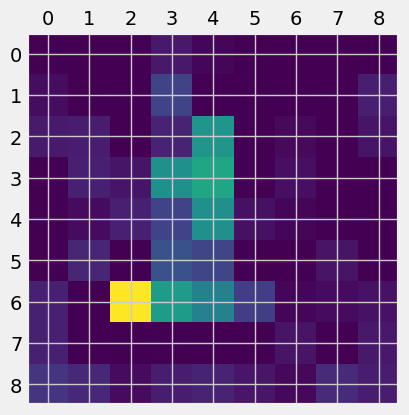

In [44]:
# Display heatmap
plt.matshow(heatmap)
plt.show()

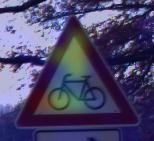

In [45]:
import matplotlib as mpl
from IPython.display import Image, display
def save_and_display_gradcam(img_path, heatmap, cam_path=data_dir+"/gradcam_output.jpg", alpha=0.4):
    # Load the original image
    img = keras.utils.load_img(img_path)
    img = keras.utils.img_to_array(img)

    # Rescale heatmap to a range 0-255
    heatmap = np.uint8(255 * heatmap)

    # Use jet colormap to colorize heatmap
    jet = mpl.colormaps["jet"]

    # Use RGB values of the colormap
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    # Create an image with RGB colorized heatmap
    jet_heatmap = keras.utils.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = keras.utils.img_to_array(jet_heatmap)

    # Superimpose the heatmap on original image
    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = keras.utils.array_to_img(superimposed_img)

    # Save the superimposed image
    superimposed_img.save(cam_path)

    # Display Grad CAM
    display(Image(cam_path))


save_and_display_gradcam(test_img_path, heatmap)


In [83]:
heatmap = cv2.resize(heatmap, (IMG_WIDTH, IMG_HEIGHT))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

original = cv2.imread(test_img_path)
original = cv2.resize(original, (IMG_WIDTH, IMG_HEIGHT))

superimposed = heatmap * 0.4 + original
cv2.imwrite(data_dir+"/gradcam_output.jpg", superimposed)
#cv2.imshow(superimposed)


True

In [84]:
print(X_test.shape)
print(heatmap.shape)

(1, 30, 30, 3)
(30, 30, 3)


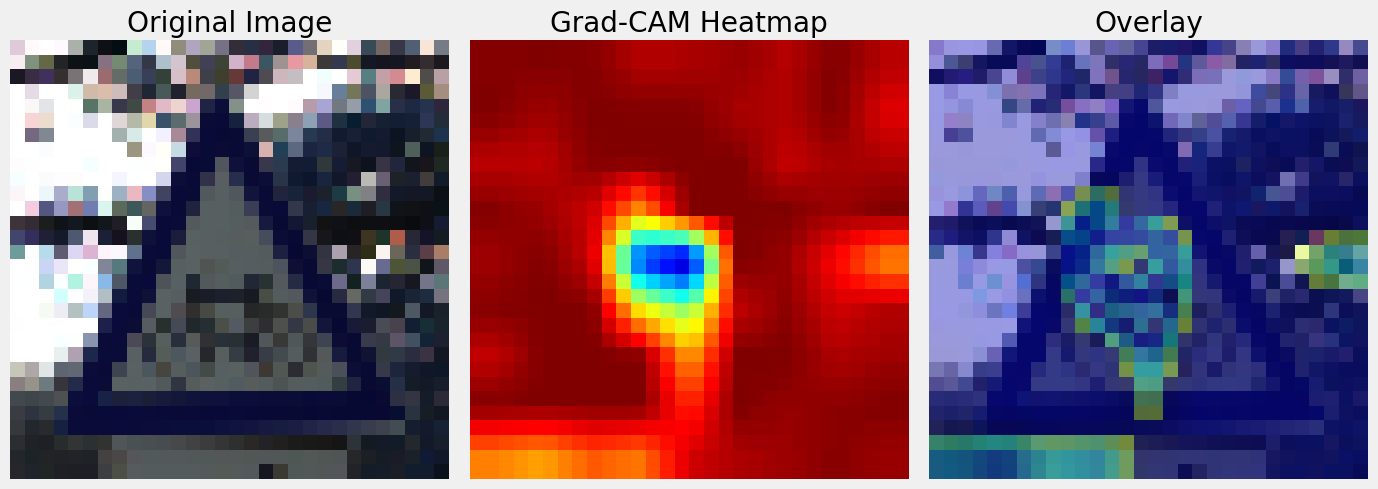

In [85]:
plt.figure(figsize=(14, 6))

# Original
plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(original.astype("uint8"))
plt.axis("off")

# Heatmap only
plt.subplot(1, 3, 2)
plt.title("Grad-CAM Heatmap")
plt.imshow(heatmap, cmap="jet")
plt.axis("off")

# Overlay
heatmap_resized = cv2.resize(heatmap, (IMG_WIDTH, IMG_HEIGHT))
heatmap_resized = np.uint8(255 * heatmap_resized)
heatmap_color = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
overlay = cv2.addWeighted(
    cv2.cvtColor(original.astype("uint8"), cv2.COLOR_RGB2BGR),
    0.6,
    heatmap_color,
    0.4,
    0
)

plt.subplot(1, 3, 3)
plt.title("Overlay")
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.tight_layout()
plt.show()


In [57]:
def show_sample(idx=None):

    # if image index is specified, get that image
    if idx:
        for img, label in test_batches.take(idx):
            sample_image = img[0]
            sample_label = label[0]
    # otherwise if idx is not specified, get a random image
    else:
        for img, label in test_batches.shuffle(1000).take(1):
            sample_image = img[0]
            sample_label = label[0]

    sample_image_processed = np.expand_dims(sample_image, axis=0)

    activations = vis_model.predict(sample_image_processed)

    pred_label = np.argmax(model.predict(sample_image_processed), axis=-1)[0]

    sample_activation = activations[0][0,:,:,16]

    sample_activation-=sample_activation.mean()
    sample_activation/=sample_activation.std()

    sample_activation *=255
    sample_activation = np.clip(sample_activation, 0, 255).astype(np.uint8)

    heatmap = get_CAM(sample_image_processed, sample_label)
    heatmap = cv2.resize(heatmap, (sample_image.shape[0], sample_image.shape[1]))
    heatmap = heatmap *255
    heatmap = np.clip(heatmap, 0, 255).astype(np.uint8)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_HOT)
    converted_img = sample_image.numpy()
    super_imposed_image = cv2.addWeighted(converted_img, 0.8, heatmap.astype('float32'), 2e-3, 0.0)

    f,ax = plt.subplots(2,2, figsize=(15,8))

    ax[0,0].imshow(sample_image)
    ax[0,0].set_title(f"True label: {sample_label} \n Predicted label: {pred_label}")
    ax[0,0].axis('off')

    ax[0,1].imshow(sample_activation)
    ax[0,1].set_title("Random feature map")
    ax[0,1].axis('off')

    ax[1,0].imshow(heatmap)
    ax[1,0].set_title("Class Activation Map")
    ax[1,0].axis('off')

    ax[1,1].imshow(super_imposed_image)
    ax[1,1].set_title("Activation map superimposed")
    ax[1,1].axis('off')
    plt.tight_layout()
    plt.show()

    return activations

In [58]:
import os
os.makedirs("./model", exist_ok=True)
cam_model.save("./model/traffic_sign_dcnn98_cam.keras")

print("\n✅ Model saved to 'traffic_sign_dcnn98_cam.keras'")


✅ Model saved to 'traffic_sign_dcnn98_cam.keras'


In [11]:
import itertools


In [12]:
grid = {
    "conv_filters": [[16,32], [32,64,128], [16,32,64,128]],
    "dropout": [True, False],
    "dropout_rate": [0.3, 0.5],
    "batchnorm": [True, False],
    "learning_rate": [1e-3, 5e-4]
}

combos = list(itertools.product(
    grid["conv_filters"],
    grid["dropout"],
    grid["dropout_rate"],
    grid["batchnorm"],
    grid["learning_rate"]
))
print(f"🔍 Total experiments: {len(combos)}")

🔍 Total experiments: 48


In [13]:
combos

[([16, 32], True, 0.3, True, 0.001),
 ([16, 32], True, 0.3, True, 0.0005),
 ([16, 32], True, 0.3, False, 0.001),
 ([16, 32], True, 0.3, False, 0.0005),
 ([16, 32], True, 0.5, True, 0.001),
 ([16, 32], True, 0.5, True, 0.0005),
 ([16, 32], True, 0.5, False, 0.001),
 ([16, 32], True, 0.5, False, 0.0005),
 ([16, 32], False, 0.3, True, 0.001),
 ([16, 32], False, 0.3, True, 0.0005),
 ([16, 32], False, 0.3, False, 0.001),
 ([16, 32], False, 0.3, False, 0.0005),
 ([16, 32], False, 0.5, True, 0.001),
 ([16, 32], False, 0.5, True, 0.0005),
 ([16, 32], False, 0.5, False, 0.001),
 ([16, 32], False, 0.5, False, 0.0005),
 ([32, 64, 128], True, 0.3, True, 0.001),
 ([32, 64, 128], True, 0.3, True, 0.0005),
 ([32, 64, 128], True, 0.3, False, 0.001),
 ([32, 64, 128], True, 0.3, False, 0.0005),
 ([32, 64, 128], True, 0.5, True, 0.001),
 ([32, 64, 128], True, 0.5, True, 0.0005),
 ([32, 64, 128], True, 0.5, False, 0.001),
 ([32, 64, 128], True, 0.5, False, 0.0005),
 ([32, 64, 128], False, 0.3, True, 0.001

In [ ]:
def compute_confusion_matrix(model, X_test, y_test, class_names):
    y_true = []
    y_pred = []
    preds = model.predict(X_test, verbose=0)
    y_true.extend(np.argmax(y_test.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

    cm = confusion_matrix(y_true, y_pred)
    return cm, y_true, y_pred

In [21]:
X_test = np.load(os.path.join('../dataset/Processed', 'X_test.npy'))
y_test = np.load(os.path.join('../dataset/Processed', 'y_test.npy'))



In [26]:
y_true = np.argmax(y_test, axis=1)

In [27]:
y_true.shape

(12630,)

In [5]:
import pandas as pd

testdf = pd.DataFrame([[1,2,3],[4,5,6]])
testdf.sum(axis=0)

0    5
1    7
2    9
dtype: int64